# People Analytics: Employee Attrition Prediction
### A clean, structured ML pipeline for predicting employee Attration

---
**Pipeline Sections:**
1. Libraries and Configuration
2. Data Loading and Quality Audit
3. Exploratory Data Analysis
4. Feature Engineering and Preprocessing
5. Model Training and Evaluation
6. Results and Business Insights

## Section 1: Libraries and Configuration

In [ ]:
# Standard libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Class imbalance (SMOTE - Synthetic Minority Over-sampling Technique) to stop model become lazy
from imblearn.over_sampling import SMOTE

# Metrics
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

# Global plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.titleweight': 'bold'})
PALETTE = ['#2ecc71', '#e74c3c']   # green = stayed, red = left

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Section 2: Data Loading and Quality Audit

In [ ]:
# ---------------------------------------------------------------
# Load dataset
# ---------------------------------------------------------------

df = pd.read_csv(r"L:\dsda itvedant\Online class\ML\Projects\people (1) .csv")

print(f'Dataset shape  : {df.shape}')
df.head()

Dataset shape  : (14999, 10)


,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


In [ ]:
df.columns

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
# ---------------------------------------------------------------
# Data quality checks: missing values, duplicates, data types
# ---------------------------------------------------------------

audit = pd.DataFrame({
    'dtype'     : df.dtypes,
    'missing'   : df.isnull().sum(),
    'missing_%' : (df.isnull().mean() * 100).round(2),
    'unique'    : df.nunique()
})
display(audit)

# Fill missing values (median for numeric, mode for categorical)
for col in df.select_dtypes(include='number'):
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print(f'Missing values after imputation : {df.isnull().sum().sum()}')
print(f'Shape after removing duplicates : {df.shape}')

,dtype,missing,missing_%,unique
satisfactoryLevel,float64,0,0.0,92
lastEvaluation,float64,0,0.0,65
numberOfProjects,int64,0,0.0,6
avgMonthlyHours,int64,0,0.0,215
timeSpent.company,int64,0,0.0,8
workAccident,int64,0,0.0,2
left,int64,0,0.0,2
promotionInLast5years,int64,0,0.0,2
dept,object,0,0.0,10
salary,object,0,0.0,3


Missing values after imputation : 0
Shape after removing duplicates : (11991, 10)


In [ ]:
# ── 3.1 Summary Statistics ────────────────────────────────────────
print('Descriptive Statistics:')
display(df.describe().T.style
        .background_gradient(cmap='Blues', subset=['mean','std'])
        .format(precision=3))

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
satisfactoryLevel,11991.000,0.630,0.241,0.090,0.480,0.660,0.820,1.000
lastEvaluation,11991.000,0.717,0.168,0.360,0.570,0.720,0.860,1.000
numberOfProjects,11991.000,3.803,1.163,2.000,3.000,4.000,5.000,7.000
avgMonthlyHours,11991.000,200.474,48.728,96.000,157.000,200.000,243.000,310.000
timeSpent.company,11991.000,3.365,1.330,2.000,3.000,3.000,4.000,10.000
workAccident,11991.000,0.154,0.361,0.000,0.000,0.000,0.000,1.000
left,11991.000,0.166,0.372,0.000,0.000,0.000,0.000,1.000
promotionInLast5years,11991.000,0.017,0.129,0.000,0.000,0.000,0.000,1.000


## Section 3: Exploratory Data Analysis

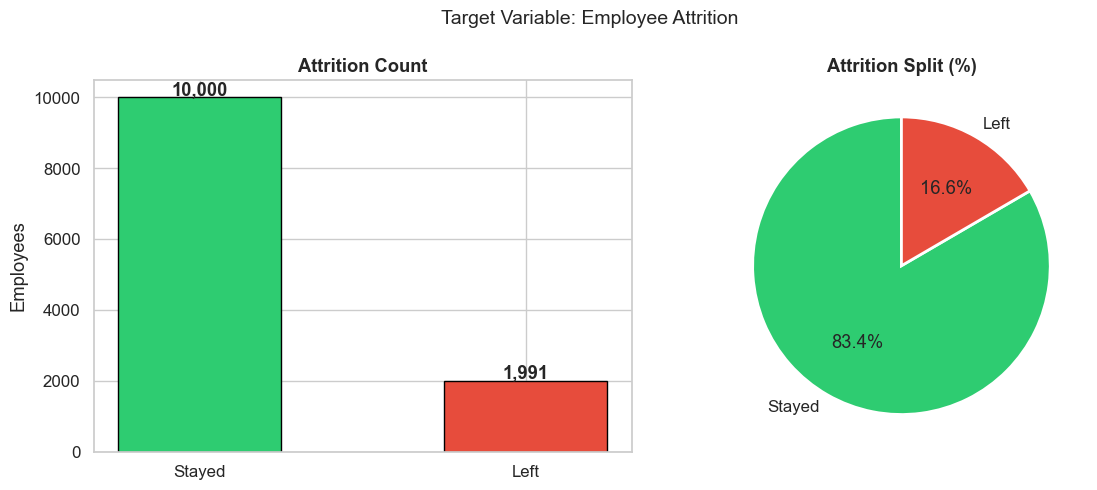

In [ ]:
# ---------------------------------------------------------------
# Target distribution: how balanced is the dataset?
# ---------------------------------------------------------------

counts = df['left'].value_counts()
labels = ['Stayed', 'Left']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(labels, counts.values, color=PALETTE, edgecolor='black', width=0.5)
axes[0].set_title('Attrition Count')
axes[0].set_ylabel('Employees')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 60, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=PALETTE, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Attrition Split (%)')

plt.suptitle('Target Variable: Employee Attrition', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print(df.columns)

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent.company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')


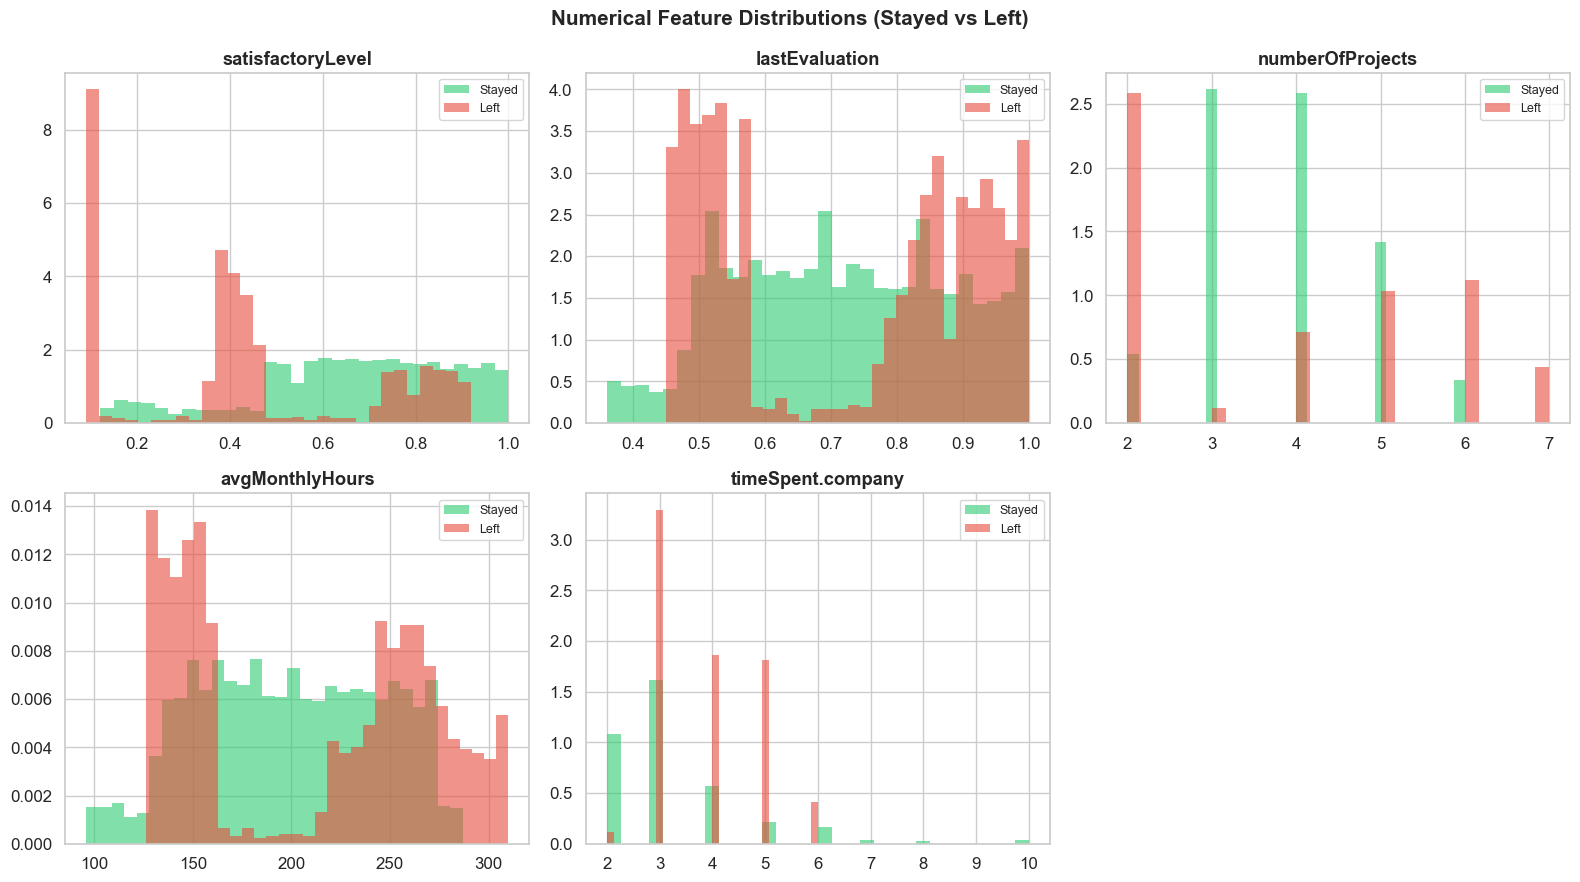

In [ ]:
# ── 3.3 Univariate — Numerical Distributions ─────────────────────
num_cols = ['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
            'avgMonthlyHours', 'timeSpent.company']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for label, grp in df.groupby('left'):
        ax.hist(grp[col], bins=30, alpha=0.6,
                color=PALETTE[label], label=['Stayed', 'Left'][label],
                edgecolor='none', density=True)
    ax.set_title(col)
    ax.legend(fontsize=9)
    ax.set_xlabel('')

axes[-1].axis('off')
plt.suptitle('Numerical Feature Distributions (Stayed vs Left)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

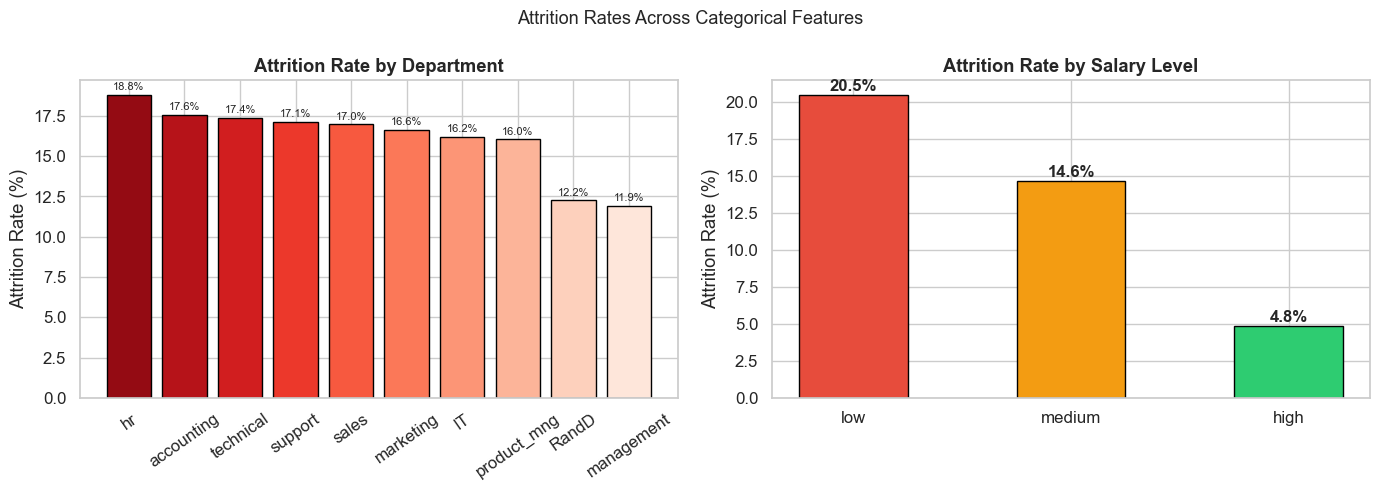

In [ ]:
# ---------------------------------------------------------------
# Attrition rates across categorical features
# Helps identify which department/salary groups are most at risk
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Attrition rate by department
dept_attr = (df.groupby('dept')['left'].mean() * 100).sort_values(ascending=False)
axes[0].bar(dept_attr.index, dept_attr.values,
            color=sns.color_palette('Reds_r', len(dept_attr)), edgecolor='black')
axes[0].set_title('Attrition Rate by Department')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=35)
for i, v in enumerate(dept_attr.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)

# Attrition rate by salary level
sal_attr = df.groupby('salary')['left'].mean() * 100
sal_attr = sal_attr.reindex(['low', 'medium', 'high'])
axes[1].bar(sal_attr.index, sal_attr.values,
            color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black', width=0.5)
axes[1].set_title('Attrition Rate by Salary Level')
axes[1].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(sal_attr.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Attrition Rates Across Categorical Features', fontsize=13)
plt.tight_layout()
plt.show()

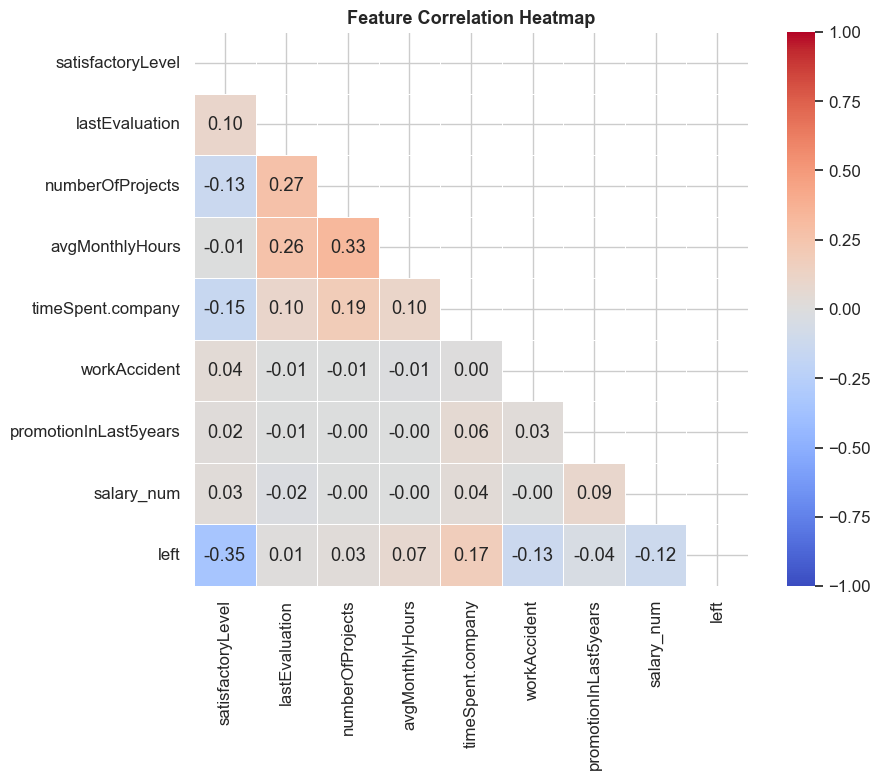

In [ ]:
# ---------------------------------------------------------------
# Correlation heatmap: identify multicollinearity and
# features most correlated with the target (left)
# ---------------------------------------------------------------

# Encode salary numerically for correlation purposes
salary_map = {'low': 1, 'medium': 2, 'high': 3}
df_corr = df.copy()
df_corr['salary_num'] = df_corr['salary'].map(salary_map)

corr_cols = ['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
             'avgMonthlyHours', 'timeSpent.company', 'workAccident',
             'promotionInLast5years', 'salary_num', 'left']

corr = df_corr[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

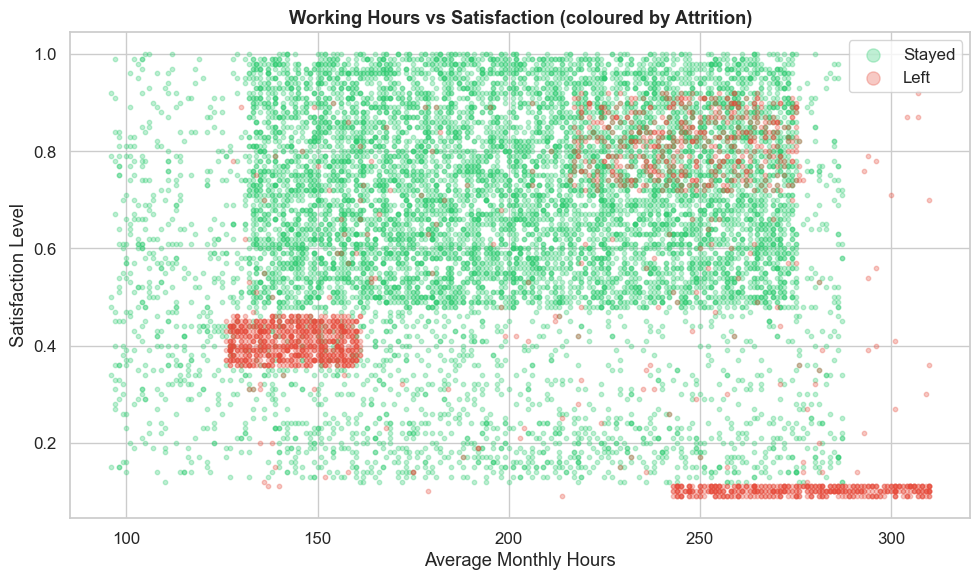

In [ ]:
# ---------------------------------------------------------------
# Satisfaction vs working hours coloured by attrition
# Reveals distinct clusters of employees who left vs stayed
# ---------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

for label, name in zip([0, 1], ['Stayed', 'Left']):
    grp = df[df['left'] == label]
    ax.scatter(grp['avgMonthlyHours'], grp['satisfactoryLevel'],
               c=PALETTE[label], alpha=0.3, s=10, label=name)

ax.set_xlabel('Average Monthly Hours')
ax.set_ylabel('Satisfaction Level')
ax.set_title('Working Hours vs Satisfaction (coloured by Attrition)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

In [ ]:
# ── 3.9 Outlier Detection via IQR ────────────────────────────────
print('Outlier Count (IQR method):')
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f'  {col:30s}: {outliers:5d}  ({outliers/len(df)*100:.2f}%)')

Outlier Count (IQR method):
  satisfactoryLevel             :     0  (0.00%)
  lastEvaluation                :     0  (0.00%)
  numberOfProjects              :     0  (0.00%)
  avgMonthlyHours               :     0  (0.00%)
  timeSpent.company             :   824  (6.87%)


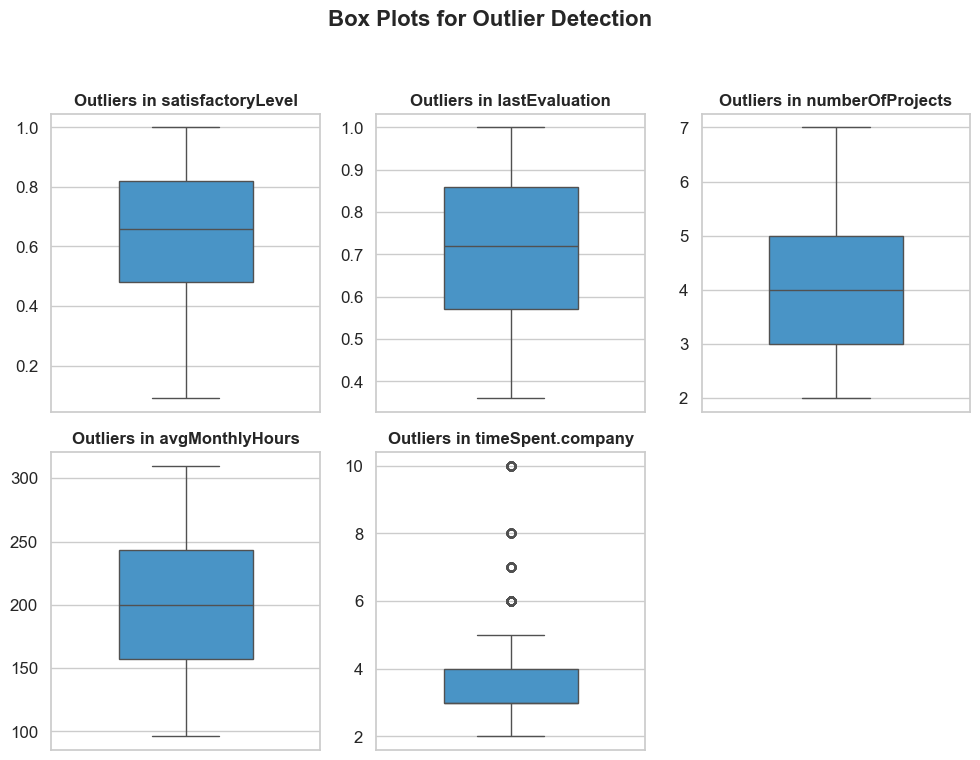

In [ ]:
# show boxplots to visually confirm outliers
# Select the same numerical columns used in your previous charts
num_cols = ['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects', 
            'avgMonthlyHours', 'timeSpent.company']

plt.figure(figsize=(10, 8))

# Create a boxplot for each column
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col], color='#3498db', width=0.5)
    plt.title(f'Outliers in {col}', fontsize=12)
    plt.ylabel('')

plt.suptitle('Box Plots for Outlier Detection', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Section 4: Feature Engineering and Preprocessing

In [ ]:
# ---------------------------------------------------------------
# Create a small set of meaningful derived features
# Each feature has a clear business interpretation
# and can help the model capture non-linear relationships
# ---------------------------------------------------------------

df_fe = df.copy()

# Hours per project: high value may indicate overload
df_fe['hours_per_project'] = df_fe['avgMonthlyHours'] / df_fe['numberOfProjects']

# Flag: senior employee with no promotion (potential disengagement signal)
df_fe['senior_no_promo'] = (
    (df_fe['timeSpent.company'] > 5) & (df_fe['promotionInLast5years'] == 0)
).astype(int)

# Flag: high performer on low salary (flight risk)
df_fe['high_eval_low_sal'] = (
    (df_fe['lastEvaluation'] > 0.75) & (df_fe['salary'] == 'low')
).astype(int)

print(f'Features before engineering : {df.shape[1]}')
print(f'Features after engineering  : {df_fe.shape[1]}')
df_fe.head(3)

Features before engineering : 10
Features after engineering  : 13


,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary,hours_per_project,senior_no_promo,high_eval_low_sal
0,0.38,0.53,2,157,3,0,1,0,sales,low,78.500000,0,0
1,0.80,0.86,5,262,6,0,1,0,sales,medium,52.400000,1,0
2,0.11,0.88,7,272,4,0,1,0,sales,medium,38.857143,0,0


In [ ]:
# ---------------------------------------------------------------
# Encoding and scaling
# - Ordinal encoding for salary (preserves order: low < medium < high)
# - One-hot encoding for department (no ordinal relationship)
# - Standard scaling for numeric features
# ---------------------------------------------------------------

df_enc = df_fe.copy()

# Ordinal encode salary
oe = OrdinalEncoder(categories=[['low', 'medium', 'high']])
df_enc['salary'] = oe.fit_transform(df_enc[['salary']])

# One-hot encode department
df_enc = pd.get_dummies(df_enc, columns=['dept'], drop_first=True)

# Standard scale continuous features
# Scaling is important for models sensitive to feature magnitudes (e.g., logistic regression)
# We include the derived feature 'hours_per_project' in scaling as well
scale_cols = ['satisfactoryLevel', 'lastEvaluation', 'avgMonthlyHours',
              'numberOfProjects', 'timeSpent.company', 'hours_per_project']
scaler = StandardScaler()
df_enc[scale_cols] = scaler.fit_transform(df_enc[scale_cols])

print(f'Final feature matrix shape: {df_enc.drop(columns=["left"]).shape}')
df_enc.head(3)

Final feature matrix shape: (11991, 20)


,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,salary,hours_per_project,...,high_eval_low_sal,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
0,-1.035668,-1.10899,-1.549921,-0.892208,-0.274291,0,1,0,0.0,1.125071,...,0,False,False,False,False,False,False,True,False,False
1,0.706637,0.85138,1.029194,1.262709,1.981036,0,1,0,1.0,-0.225324,...,0,False,False,False,False,False,False,True,False,False
2,-2.155721,0.97019,2.748604,1.467939,0.477485,0,1,0,1.0,-0.926021,...,0,False,False,False,False,False,False,True,False,False


In [ ]:
# ---------------------------------------------------------------
# Train/test split with stratification to preserve class ratio
# Apply SMOTE only on training data to handle class imbalance
# ---------------------------------------------------------------

# Separate features and target
X = df_enc.drop(columns=['left'])
y = df_enc['left']

# Stratify to maintain the same proportion of 'left' classes in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train size before SMOTE : {X_train.shape[0]}')
print(f'Class distribution      : {dict(y_train.value_counts())}')

# (SMOTE - Synthetic Minority Over-sampling Technique) to stop model become lazy
# Oversample minority class (left=1) using SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f'Train size after SMOTE  : {X_train_res.shape[0]}')
print(f'Class distribution      : {dict(pd.Series(y_train_res).value_counts())}')

# Training Set (X_train): 9,592 employees (80% of your data).
# Training (Balanced)	15,998
# Test Set (X_test): 2,399 employees (20% of your data).

Train size before SMOTE : 9592
Class distribution      : {0: np.int64(7999), 1: np.int64(1593)}
Train size after SMOTE  : 15998
Class distribution      : {0: np.int64(7999), 1: np.int64(7999)}


## Section 5: Model Training and Evaluation

In [ ]:
# ---------------------------------------------------------------
# Define four models covering different learning strategies:
#   1. Logistic Regression  - linear, interpretable baseline
#   2. Decision Tree        - non-linear, rule-based baseline
#   3. Random Forest        - bagging ensemble, robust to noise
#   4. Gradient Boosting    - sequential boosting, high accuracy
# ---------------------------------------------------------------

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=0.5, random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=20, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        max_features='sqrt', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=5, subsample=0.8, random_state=42
    )
}

# k-fold cross-validation setup for robust performance estimation

# it take 4 fold for test and 1 fold for validation(train) and it will shuffle the data before splitting into folds to ensure randomness and reduce bias
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []


for name, model in models.items():
    # Train on SMOTE-balanced training set
    model.fit(X_train_res, y_train_res)

    # Predict on held-out test set
    y_pred = model.predict(X_test)
    # Get predicted probabilities for ROC-AUC calculation
    y_prob = model.predict_proba(X_test)[:, 1]

    # Cross-validated AUC on training data
    # ROC - (Receiver Operating Characteristic) curve
    # AUC - (Area Under the Curve)
    cv_auc = cross_val_score(model, X_train_res, y_train_res,
                             cv=cv, scoring='roc_auc', n_jobs=-1).mean()

    results.append({
        'Model'         : name,
        'Accuracy'      : accuracy_score(y_test, y_pred),
        'F1 Score'      : f1_score(y_test, y_pred),
        'ROC-AUC'       : roc_auc_score(y_test, y_prob),
        'CV-AUC (train)': cv_auc,
        '_model'        : model,
        '_prob'         : y_prob,
        '_pred'         : y_pred
    })
    print(f'{name:25s} | AUC: {roc_auc_score(y_test, y_prob):.4f} | F1: {f1_score(y_test, y_pred):.4f}')

print('\nAll models trained.')

Logistic Regression       | AUC: 0.8635 | F1: 0.5846
Decision Tree             | AUC: 0.9668 | F1: 0.8430
Random Forest             | AUC: 0.9805 | F1: 0.9459
Gradient Boosting         | AUC: 0.9845 | F1: 0.9416

All models trained.


In [ ]:
# ---------------------------------------------------------------
# Model leaderboard: summary of all evaluation metrics
# ---------------------------------------------------------------

leaderboard = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in results
]).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

display(leaderboard.style
        .background_gradient(cmap='Greens',
                             subset=['Accuracy', 'F1 Score', 'ROC-AUC', 'CV-AUC (train)'])
        .format({'Accuracy': '{:.4f}', 'F1 Score': '{:.4f}',
                 'ROC-AUC': '{:.4f}', 'CV-AUC (train)': '{:.4f}'}))

# Cross-validated AUC on training data
# ROC - (Receiver Operating Characteristic) curve
# AUC - (Area Under the Curve)

,Model,Accuracy,F1 Score,ROC-AUC,CV-AUC (train)
0,Gradient Boosting,0.9808,0.9416,0.9845,0.9970
1,Random Forest,0.9825,0.9459,0.9805,0.9967
2,Decision Tree,0.9416,0.8430,0.9668,0.9819
3,Logistic Regression,0.8003,0.5846,0.8635,0.8632


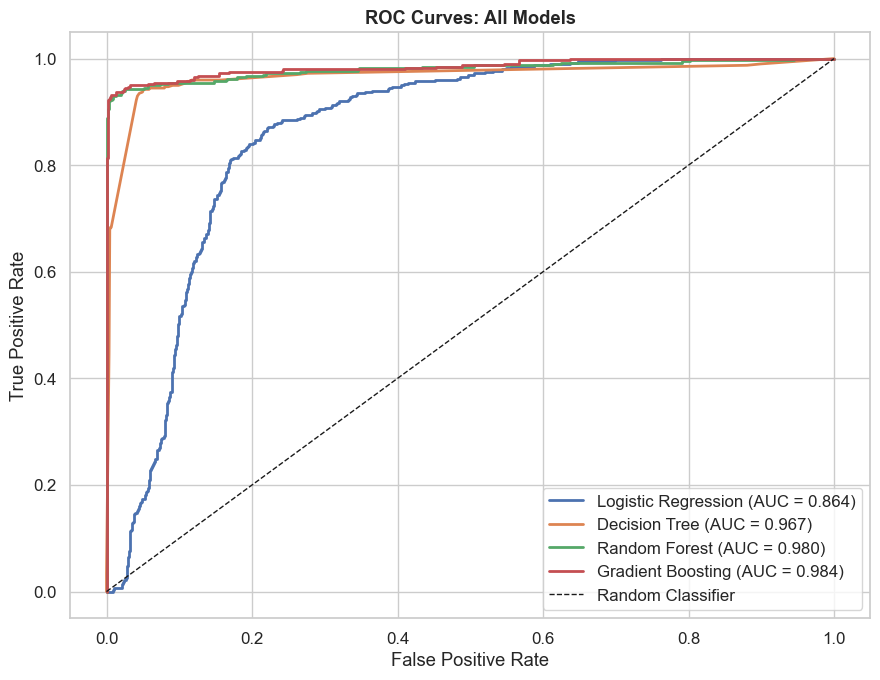

In [ ]:
# ---------------------------------------------------------------
# ROC curves for all models on the test set
# Higher and further left = better discrimination
# ---------------------------------------------------------------

plt.figure(figsize=(9, 7))

for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['_prob'])
    plt.plot(fpr, tpr, lw=2, label=f"{r['Model']} (AUC = {r['ROC-AUC']:.3f})")

# Diagonal represents random classification
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Best Model: Gradient Boosting
ROC-AUC   : 0.9845
F1 Score  : 0.9416
Accuracy  : 0.9808

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.99      0.99      0.99      2001
        Left       0.95      0.93      0.94       398

    accuracy                           0.98      2399
   macro avg       0.97      0.96      0.97      2399
weighted avg       0.98      0.98      0.98      2399



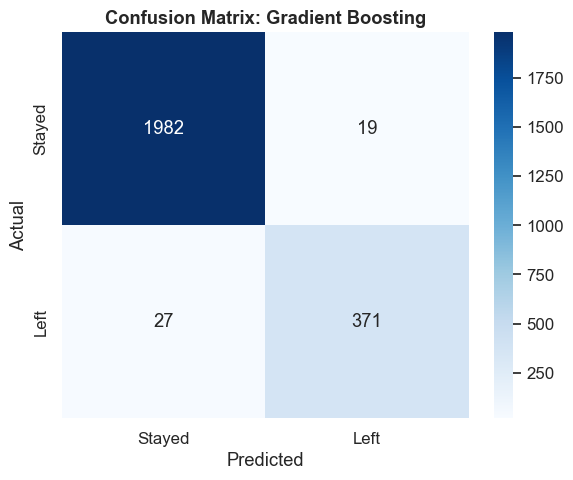

In [ ]:
# ---------------------------------------------------------------
# Confusion matrix and classification report for the best model
# Best model is selected based on highest ROC-AUC, as it captures overall discrimination ability across all thresholds
# ---------------------------------------------------------------

# Select best model by ROC-AUC
best = max(results, key=lambda r: r['ROC-AUC'])
print(f'Best Model: {best["Model"]}')
print(f'ROC-AUC   : {best["ROC-AUC"]:.4f}')
print(f'F1 Score  : {best["F1 Score"]:.4f}')
print(f'Accuracy  : {best["Accuracy"]:.4f}\n')

print('Classification Report:')
print(classification_report(y_test, best['_pred'], target_names=['Stayed', 'Left']))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, best['_pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title(f'Confusion Matrix: {best["Model"]}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

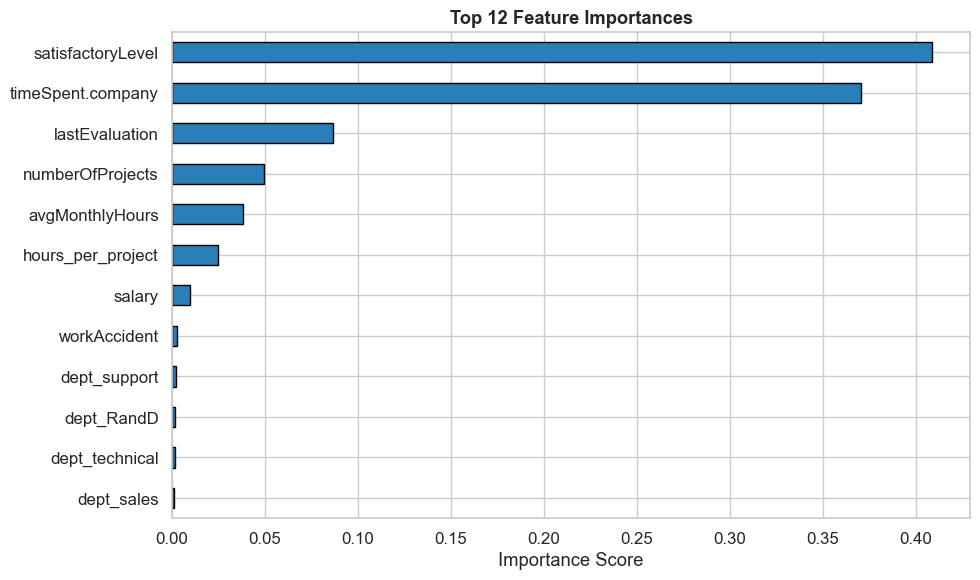

In [ ]:
# ---------------------------------------------------------------
# Feature importance from the best tree-based model
# Higher importance = greater contribution to predictions
# ---------------------------------------------------------------

# Use Random Forest or Gradient Boosting for feature importance
tree_model = next(r['_model'] for r in results
                  if r['Model'] in ('Random Forest', 'Gradient Boosting')
                  and r['ROC-AUC'] == max(r['ROC-AUC'] for r in results
                                          if r['Model'] in ('Random Forest', 'Gradient Boosting')))

importance = pd.Series(tree_model.feature_importances_,
                        index=X_train.columns).sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
importance.sort_values().plot(kind='barh', color='#2980b9', edgecolor='black')
plt.title('Top 12 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Section 6: Results and Business Insights

In [ ]:
# Create a dataframe of employees in the test set with their risk scores
risk_df = X_test.copy()
risk_df['Actual_Left'] = y_test
risk_df['Retention_Risk_Score'] = best['_prob'] # Probability from your best model

# Filter for Top Talent who are likely to leave but haven't yet
# We use the original 'df' indices to get unscaled values for readability
priority_list = risk_df[(risk_df['Retention_Risk_Score'] > 0.7) & (risk_df['Actual_Left'] == 0)]

print(f"ALERT: Identified {len(priority_list)} High-Risk employees for immediate retention interviews.")
display(priority_list[['Retention_Risk_Score']].sort_values(by='Retention_Risk_Score', ascending=False).head(10))

ALERT: Identified 12 High-Risk employees for immediate retention interviews.


,Retention_Risk_Score
10742,0.983683
7091,0.983070
2964,0.981291
3716,0.978535
4699,0.951403
14585,0.893038
12291,0.888644
7148,0.865600
6430,0.823490
2613,0.778226


In [ ]:
# ---------------------------------------------------------------
# Final model performance summary
# ---------------------------------------------------------------


leaderboard.index = leaderboard.index + 1  # Start index from 1 for better readability

print('=' * 52)
print('     FINAL MODEL LEADERBOARD (by ROC-AUC)')
print('=' * 52)

display(leaderboard.style
        .background_gradient(cmap='RdYlGn', subset=['ROC-AUC', 'F1 Score'])
        .format({'Accuracy': '{:.4f}', 'F1 Score': '{:.4f}',
                 'ROC-AUC': '{:.4f}', 'CV-AUC (train)': '{:.4f}'}))

     FINAL MODEL LEADERBOARD (by ROC-AUC)


,Model,Accuracy,F1 Score,ROC-AUC,CV-AUC (train)
1,Gradient Boosting,0.9808,0.9416,0.9845,0.9970
2,Random Forest,0.9825,0.9459,0.9805,0.9967
3,Decision Tree,0.9416,0.8430,0.9668,0.9819
4,Logistic Regression,0.8003,0.5846,0.8635,0.8632


In [ ]:
# ---------------------------------------------------------------
# Business insights derived from EDA and feature importance
# ---------------------------------------------------------------

print("""
KEY RISK FACTORS (from EDA and feature importance)
---------------------------------------------------
1. Low satisfaction level (<0.40) is the strongest attrition predictor.
2. Overwork (>250 hrs/month) correlates strongly with turnover.
3. Low salary employees leave at a significantly higher rate.
4. Senior employees (>5 yrs) who have not been promoted show high attrition.
5. Employees with 6+ projects are more likely to leave (overload signal).

RECOMMENDATIONS
---------------------------------------------------
1. Introduce quarterly satisfaction surveys with action plans.
2. Set a soft cap of 4-5 projects per employee at any given time.
3. Review compensation for high performers on low salary bands.
4. Build clear promotion pathways for employees beyond year 4.
5. Flag employees exceeding 250 hrs/month for manager check-ins.

DEPLOYMENT NOTE
---------------------------------------------------
The best-performing model can be serialised (joblib/pickle) and
deployed as a batch scoring pipeline to generate monthly attrition
risk scores for all active employees.
""")


KEY RISK FACTORS (from EDA and feature importance)
---------------------------------------------------
1. Low satisfaction level (<0.40) is the strongest attrition predictor.
2. Overwork (>250 hrs/month) correlates strongly with turnover.
3. Low salary employees leave at a significantly higher rate.
4. Senior employees (>5 yrs) who have not been promoted show high attrition.
5. Employees with 6+ projects are more likely to leave (overload signal).

RECOMMENDATIONS
---------------------------------------------------
1. Introduce quarterly satisfaction surveys with action plans.
2. Set a soft cap of 4-5 projects per employee at any given time.
3. Review compensation for high performers on low salary bands.
4. Build clear promotion pathways for employees beyond year 4.
5. Flag employees exceeding 250 hrs/month for manager check-ins.

DEPLOYMENT NOTE
---------------------------------------------------
The best-performing model can be serialised (joblib/pickle) and
deployed as a batch scor

In [ ]:
# import pickle
# import os

# # Ensure the model exists in memory first
# if 'tree_model' in locals():
#     filename = 'attrition_prediction_model.pkl'
    
#     # Using 'wb' (write binary) mode
#     with open(filename, 'wb') as f:
#         pickle.dump(tree_model, f)
    
#     print(f"Success! File saved. Size: {os.path.getsize(filename)} bytes")
# else:
#     print("Error: 'tree_model' not found. Please run the Model Training cell first!")

In [ ]:
import os
import joblib

# Saving the model
joblib.dump(tree_model, 'attrition_model.joblib')

# Loading the model
loaded_model = joblib.load('attrition_model.joblib')
print(f"Model file size: {os.path.getsize('attrition_model.joblib')} bytes")    
print("Model saved and loaded successfully.")



Model file size: 901705 bytes
Model saved and loaded successfully.
